# Análisis de Series Temporales — TP N.º 1
## Tercera serie: altitud de un vehículo aéreo no tripulado

Maestría en Ciencia de Datos — Universidad Austral

Este documento resuelve los puntos **1 a 9 y 12** de la consigna sobre la tercera serie del trabajo.
Los puntos **10 y 11** (modelo VAR, función impulso-respuesta y causalidad de Granger) se resuelven
en `resolucion_consigna_series_bodegaai.ipynb` con las series ALB y POS API; el motivo por el cual
esta serie no participa de aquel modelo se expone en la sección final.

## 1. Problemática de interés analítico y elección de la serie

*(Punto 1 de la consigna)*

La serie analizada es la **altitud relativa de un vehículo aéreo no tripulado de ala fija** durante un
vuelo completo. El dato proviene de un registro de telemetría MAVLink (`.tlog`), el formato con el que
el piloto automático ArduPilot transmite el estado de la aeronave a la estación de tierra.

El interés analítico es doble. Por un lado, la altitud es la variable que sintetiza el estado energético
de la aeronave y su predicción de corto plazo resulta relevante para la supervisión automática del vuelo
y para la detección de anomalías. Por otro, la serie presenta las características que el trabajo requiere:
no estacionariedad en niveles, estructura autorregresiva remanente tras la diferenciación y un modelo con
diagnóstico de residuos satisfactorio.

**Fuente descartada.** El conjunto `data/SurveilDrone-Net23.csv` fue evaluado en primer término y
descartado. Sus veinticinco variables numéricas constituyen ruido blanco independiente e idénticamente
distribuido: la función de autocorrelación permanece dentro de la banda de significatividad en todos los
rezagos examinados, la prueba de Ljung-Box nunca rechaza la hipótesis de incorrelación, la temperatura
ambiente permanece constante en 25,0 °C durante los cuarenta y ocho meses del registro y cada día contiene
exactamente noventa y seis observaciones. Tal estructura impide resolver los puntos 5 a 9 con contenido
analítico. El detalle de la evidencia consta en `notas_serie3_uav_altitud.md`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pymavlink import mavutil
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

### 1.1 Lectura del registro de telemetría

El vuelo seleccionado es `data/telemetry/2018-07-18/flight7/flight.tlog`. La variable extraída es
`relative_alt` del mensaje `GLOBAL_POSITION_INT`, expresada en milímetros sobre el punto de despegue y
convertida a metros.

Se prefirió `GLOBAL_POSITION_INT.relative_alt` sobre `VFR_HUD.alt` por tres razones: la primera está
referida al punto de despegue y resulta de lectura directa como altura de vuelo, mientras que la segunda
arrastra un desplazamiento sobre el nivel del mar de aproximadamente 345 metros que no aporta información;
la primera se muestrea a 4,15 Hz frente a 2,6 Hz de la segunda; y la primera permite detectar el contacto
con el suelo sin conocer la elevación del campo de vuelo.

In [2]:
TLOG = "../data/telemetry/2018-07-18/flight7/flight.tlog"


def leer_altitud(ruta):
    """Extrae la altitud relativa, en metros, de un registro de telemetria MAVLink."""
    conexion = mavutil.mavlink_connection(ruta)
    registros = []
    while True:
        mensaje = conexion.recv_match(type="GLOBAL_POSITION_INT")
        if mensaje is None:
            break
        registros.append((mensaje._timestamp, mensaje.relative_alt / 1000.0))

    crudo = pd.DataFrame(registros, columns=["timestamp", "altitud_m"])
    crudo["timestamp"] = pd.to_datetime(crudo["timestamp"], unit="s")
    return crudo.set_index("timestamp")["altitud_m"]


crudo = leer_altitud(TLOG)
dt_mediano = np.median(np.diff(crudo.index.values)) / np.timedelta64(1, "s")

print(f"Mensajes leidos      : {len(crudo):,}")
print(f"Inicio del registro  : {crudo.index[0]}")
print(f"Fin del registro     : {crudo.index[-1]}")
print(f"Intervalo mediano    : {dt_mediano:.3f} s  ({1 / dt_mediano:.2f} Hz)")

Mensajes leidos      : 3,784
Inicio del registro  : 2018-07-18 19:52:17.699123859
Fin del registro     : 2018-07-18 20:07:45.578007936
Intervalo mediano    : 0.241 s  (4.15 Hz)


### 1.2 Construcción de la serie: tramo en vuelo y grilla regular

El registro completo abarca mucho más que el vuelo: la mayor parte corresponde a la aeronave detenida en
tierra, donde la altitud registrada es únicamente deriva del barómetro. Modelar ese tramo carecería de
sentido, de modo que se conserva el **bloque contiguo más largo** con altitud superior a 3 metros.

El umbral de 3 metros preserva el despegue y el descenso, que aportan la dinámica más informativa. Un
umbral más exigente reduciría el tramo sin mejorar el análisis.

La serie se lleva a una **grilla regular de 1 Hz**. Dado que la frecuencia nativa ronda los 4,15 Hz, la
operación constituye un submuestreo y no introduce puntos interpolados, lo cual evita inflar
artificialmente la autocorrelación de rezago corto sobre la que se apoya la identificación del modelo.

In [3]:
UMBRAL_VUELO_M = 3.0

por_segundo = crudo.resample("1s").mean()
print(f"Intervalos vacios tras el remuestreo a 1 Hz: {int(por_segundo.isna().sum())}")


def bloque_contiguo_mas_largo(mascara):
    """Devuelve los indices de inicio y fin del tramo contiguo mas largo que cumple la mascara."""
    mejor_inicio, mejor_largo = 0, 0
    inicio = None
    for posicion, activo in enumerate(mascara):
        if activo and inicio is None:
            inicio = posicion
        elif not activo and inicio is not None:
            if posicion - inicio > mejor_largo:
                mejor_inicio, mejor_largo = inicio, posicion - inicio
            inicio = None
    if inicio is not None and len(mascara) - inicio > mejor_largo:
        mejor_inicio, mejor_largo = inicio, len(mascara) - inicio
    return mejor_inicio, mejor_inicio + mejor_largo


desde, hasta = bloque_contiguo_mas_largo((por_segundo > UMBRAL_VUELO_M).to_numpy())

serie = por_segundo.iloc[desde:hasta].reset_index(drop=True)
serie.index.name = "segundo de vuelo"
serie.name = "altitud_m"

print(f"Observaciones        : {len(serie)}")
print(f"Duracion             : {len(serie)} s  ({len(serie) / 60:.1f} min)")
print(f"Altitud minima       : {serie.min():.1f} m")
print(f"Altitud maxima       : {serie.max():.1f} m")
print(f"Altitud media        : {serie.mean():.1f} m")

Intervalos vacios tras el remuestreo a 1 Hz: 0
Observaciones        : 457
Duracion             : 457 s  (7.6 min)
Altitud minima       : 4.9 m
Altitud maxima       : 82.8 m
Altitud media        : 46.9 m


## 2. Serie original, estacionariedad y diferenciación

*(Punto 2 de la consigna)*

Una serie es **estacionaria en sentido débil** cuando su media y su varianza son constantes en el tiempo y
su autocovarianza entre dos momentos depende únicamente de la distancia que los separa, no del instante en
que se los observe. Los modelos ARMA suponen esa propiedad: sin ella, las estimaciones pierden validez y
las relaciones detectadas pueden resultar espurias.

El gráfico siguiente muestra la serie en niveles y su primera diferencia.

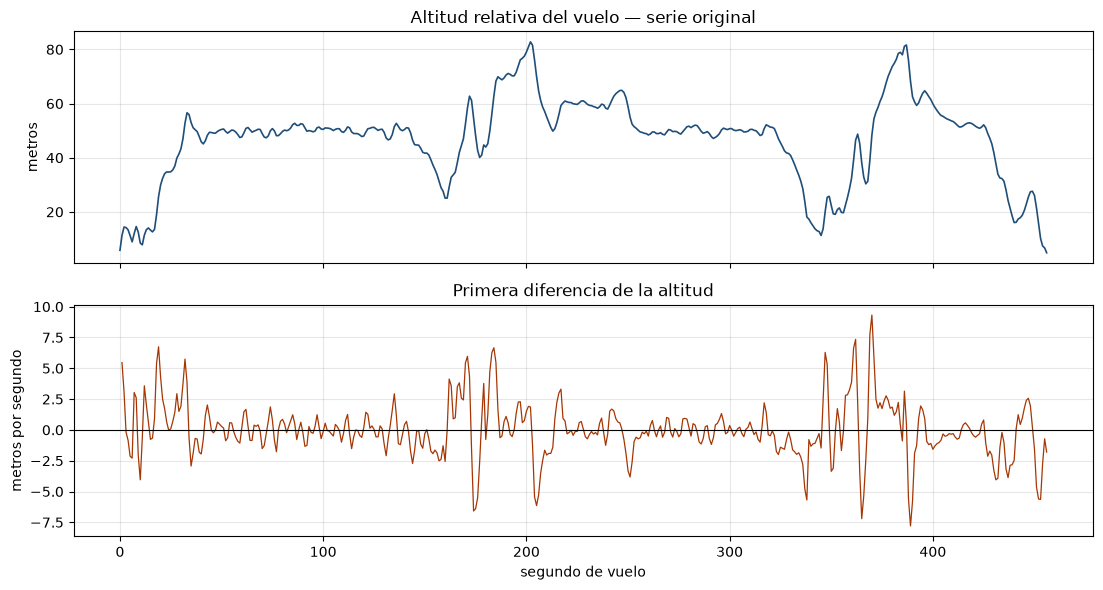

In [4]:
diferenciada = serie.diff().dropna()

figura, ejes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ejes[0].plot(serie.index, serie.values, color="#1f4e79", linewidth=1.2)
ejes[0].set_title("Altitud relativa del vuelo — serie original")
ejes[0].set_ylabel("metros")

ejes[1].plot(diferenciada.index, diferenciada.values, color="#a63603", linewidth=0.9)
ejes[1].axhline(0, color="black", linewidth=0.8)
ejes[1].set_title("Primera diferencia de la altitud")
ejes[1].set_ylabel("metros por segundo")
ejes[1].set_xlabel("segundo de vuelo")

plt.tight_layout()
plt.show()

La serie en niveles recorre las fases de despegue, ascenso, crucero y descenso. La media no es constante:
se desplaza de manera sostenida a lo largo del vuelo, lo cual constituye evidencia visual de no
estacionariedad. La primera diferencia, en cambio, oscila alrededor de cero con una dispersión
razonablemente estable, comportamiento compatible con una serie ya estacionaria.

## 3. Función de autocovarianza, autocorrelación y autocorrelación parcial

*(Punto 3 de la consigna)*

Las tres funciones se presentan en un mismo gráfico, para la serie en niveles y para la diferenciada.

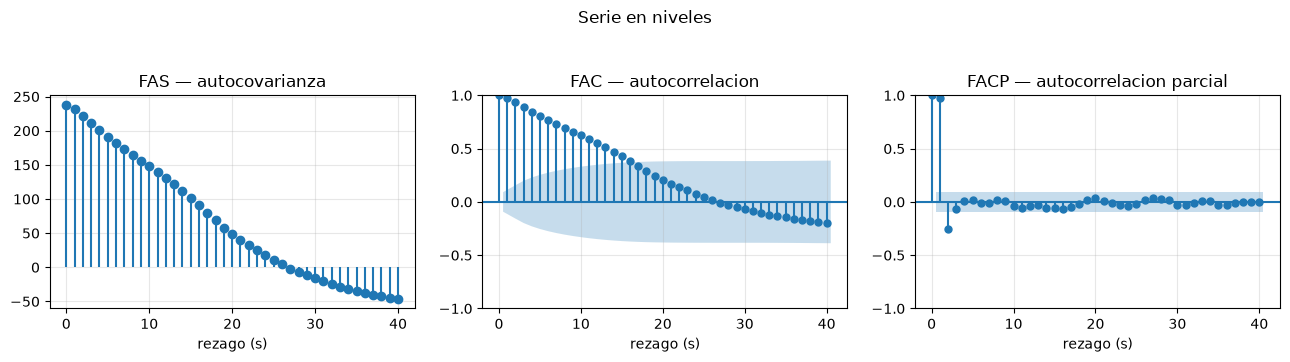

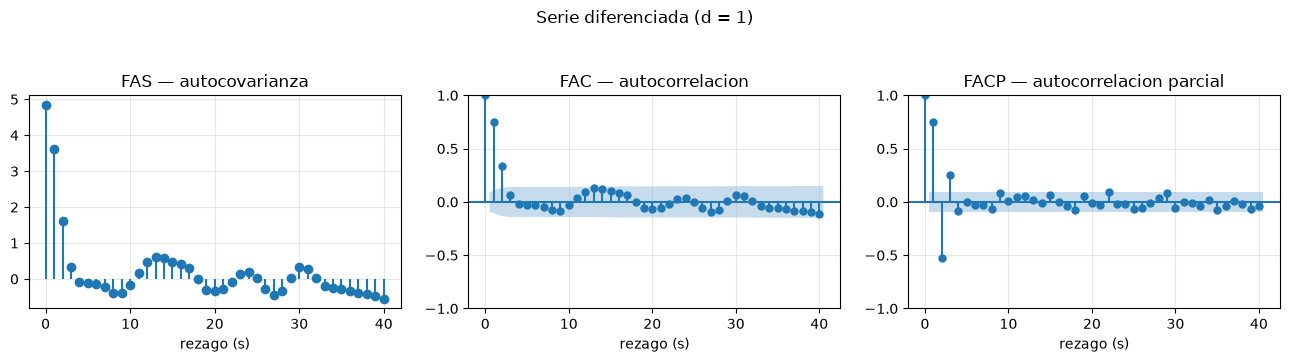

In [5]:
def graficar_fas_fac_facp(datos, titulo, rezagos=40):
    """Grafica la funcion de autocovarianza, la de autocorrelacion y la parcial en una sola figura."""
    figura, ejes = plt.subplots(1, 3, figsize=(13, 3.4))

    autocovarianza = sm.tsa.acovf(datos, nlag=rezagos, fft=True)
    ejes[0].stem(range(len(autocovarianza)), autocovarianza, basefmt=" ")
    ejes[0].set_title("FAS — autocovarianza")

    plot_acf(datos, lags=rezagos, ax=ejes[1], title="FAC — autocorrelacion")
    plot_pacf(datos, lags=rezagos, ax=ejes[2], method="ywm", title="FACP — autocorrelacion parcial")

    for eje in ejes:
        eje.set_xlabel("rezago (s)")
    figura.suptitle(titulo, y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()


graficar_fas_fac_facp(serie, "Serie en niveles")
graficar_fas_fac_facp(diferenciada, "Serie diferenciada (d = 1)")

**Lectura de los gráficos.** En niveles, la FAC decae de manera lenta y aproximadamente lineal, y permanece
muy por encima de la banda de significatividad durante decenas de rezagos. La FACP, en cambio, presenta un
primer rezago cercano a la unidad y se corta de inmediato. La teoría asocia ese par de patrones a un
proceso **integrado**: la persistencia no proviene de una memoria autorregresiva de orden alto sino de la
presencia de una raíz unitaria, y el remedio es la diferenciación.

Tras aplicar una diferencia regular, la FAC pierde la persistencia y sólo conserva significatividad en los
primeros rezagos, lo cual sugiere una componente de medias móviles de orden bajo. La FACP muestra un
decaimiento compatible con esa misma lectura. El material así identificado corresponde a un modelo
ARIMA(p, 1, q) con órdenes reducidos.

## 4. Pruebas de raíces unitarias

*(Punto 4 de la consigna)*

Se aplican dos pruebas de hipótesis complementarias. La **Dickey-Fuller aumentada (ADF)** plantea como
hipótesis nula la existencia de una raíz unitaria, es decir, la no estacionariedad. La **KPSS** invierte los
papeles: su nula es la estacionariedad. El uso conjunto de ambas evita una lectura mecánica basada en un
único contraste.

Se agrega la prueba de **Ljung-Box** sobre la serie diferenciada, que contrasta la hipótesis nula de
incorrelación conjunta hasta un rezago dado.

In [6]:
def resumen_pruebas(datos, etiqueta):
    """Calcula ADF, KPSS y Ljung-Box sobre una serie y devuelve una fila de resultados."""
    p_adf = adfuller(datos)[1]
    p_kpss = kpss(datos, nlags="auto")[1]
    p_ljung = acorr_ljungbox(datos, lags=[20], return_df=True)["lb_pvalue"].iloc[0]
    return {
        "serie": etiqueta,
        "ADF (p)": p_adf,
        "ADF concluye": "no estacionaria" if p_adf > 0.05 else "estacionaria",
        "KPSS (p)": p_kpss,
        "KPSS concluye": "estacionaria" if p_kpss > 0.05 else "no estacionaria",
        "Ljung-Box 20 (p)": p_ljung,
    }


pruebas = pd.DataFrame(
    [resumen_pruebas(serie, "niveles"), resumen_pruebas(diferenciada, "diferencia d = 1")]
)
pruebas.style.format({"ADF (p)": "{:.4f}", "KPSS (p)": "{:.4f}", "Ljung-Box 20 (p)": "{:.3e}"})

,serie,ADF (p),ADF concluye,KPSS (p),KPSS concluye,Ljung-Box 20 (p)
0,niveles,0.1237,no estacionaria,0.1000,estacionaria,0.000e+00
1,diferencia d = 1,0.0000,estacionaria,0.1000,estacionaria,1.115e-62


**Interpretación.** Sobre la serie en niveles, la prueba ADF no rechaza la hipótesis nula de raíz unitaria,
lo cual constituye evidencia de no estacionariedad. La KPSS, por su parte, tampoco rechaza su propia nula
de estacionariedad. Las dos pruebas no coinciden.

Tal discrepancia es un resultado frecuente en muestras de tamaño moderado y no invalida el análisis: indica
que la evidencia muestral no basta para pronunciarse de manera categórica con un único contraste. La
decisión de diferenciar se sostiene sobre tres elementos convergentes: el desplazamiento visible de la media
en el gráfico de niveles, el decaimiento lento de la FAC junto con el corte abrupto de la FACP, y la
ausencia de rechazo por parte de la ADF. La literatura recomienda diferenciar ante evidencia de raíz
unitaria, dado que el costo de sobrediferenciar resulta menor que el de estimar sobre una serie integrada.

Sobre la serie diferenciada, la prueba de Ljung-Box rechaza de manera contundente la incorrelación. Ese es
el resultado central de esta sección: **tras eliminar la raíz unitaria subsiste estructura autocorrelacionada
genuina**, y por lo tanto existe un modelo ARMA por estimar.

## 5. Estimación de modelos y selección de órdenes

*(Puntos 5 y 12 de la consigna)*

Se estima una grilla de modelos ARIMA(p, 1, q) con p y q entre 0 y 3. La diferencia regular se fija en
d = 1 conforme al análisis de la sección anterior. La comparación emplea los criterios de información de
Akaike (AIC) y bayesiano (BIC), que penalizan la cantidad de parámetros y permiten contrastar modelos no
anidados.

In [7]:
HORIZONTE = 15

entrenamiento = serie.iloc[:-HORIZONTE]
prueba = serie.iloc[-HORIZONTE:]

resultados = []
for p in range(4):
    for q in range(4):
        try:
            ajuste = ARIMA(entrenamiento, order=(p, 1, q)).fit()
            pronostico = ajuste.forecast(HORIZONTE)
            error = pronostico.to_numpy() - prueba.to_numpy()
            resultados.append(
                {
                    "modelo": f"ARIMA({p},1,{q})",
                    "AIC": ajuste.aic,
                    "BIC": ajuste.bic,
                    "MAE": np.mean(np.abs(error)),
                    "RMSE": np.sqrt(np.mean(error**2)),
                    "Ljung-Box residuos (p)": acorr_ljungbox(
                        ajuste.resid[1:], lags=[20], return_df=True
                    )["lb_pvalue"].iloc[0],
                }
            )
        except Exception as excepcion:
            print(f"ARIMA({p},1,{q}) no convergio: {excepcion}")

comparacion = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
comparacion.style.format(
    {"AIC": "{:.2f}", "BIC": "{:.2f}", "MAE": "{:.3f}", "RMSE": "{:.3f}",
     "Ljung-Box residuos (p)": "{:.3f}"}
).background_gradient(subset=["AIC"], cmap="Blues_r")

,modelo,AIC,BIC,MAE,RMSE,Ljung-Box residuos (p)
0,"ARIMA(1,1,3)",1379.95,1400.40,6.013,7.534,0.631
1,"ARIMA(0,1,3)",1380.36,1396.72,5.989,7.567,0.602
2,"ARIMA(2,1,3)",1381.68,1406.21,6.004,7.552,0.653
3,"ARIMA(3,1,3)",1383.19,1411.81,5.991,7.553,0.654
4,"ARIMA(3,1,1)",1387.43,1407.87,6.007,7.495,0.468
5,"ARIMA(2,1,1)",1387.49,1403.85,5.963,7.519,0.489
6,"ARIMA(2,1,2)",1387.87,1408.31,5.983,7.518,0.437
7,"ARIMA(3,1,0)",1389.23,1405.59,6.061,7.461,0.226
8,"ARIMA(3,1,2)",1389.27,1413.80,6.000,7.507,0.442
9,"ARIMA(1,1,2)",1390.47,1406.83,5.956,7.510,0.233


In [8]:
orden_elegido = tuple(int(v) for v in comparacion.loc[0, "modelo"][6:-1].split(","))
modelo = ARIMA(entrenamiento, order=orden_elegido).fit()

print(f"Modelo seleccionado por AIC: ARIMA{orden_elegido}\n")
print(modelo.summary())

Modelo seleccionado por AIC: ARIMA(1, 1, 3)

                               SARIMAX Results                                
Dep. Variable:              altitud_m   No. Observations:                  442
Model:                 ARIMA(1, 1, 3)   Log Likelihood                -684.976
Date:                Sun, 23 Aug 2026   AIC                           1379.951
Time:                        14:27:55   BIC                           1400.397
Sample:                             0   HQIC                          1388.016
                                - 442                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2650      0.120     -2.208      0.027      -0.500      -0.030
ma.L1          1.6263      0.113     14.432      0.000       1.405       1.847
ma.L2  

In [9]:
# Significatividad global: razon de verosimilitud contra el modelo sin parametros ARMA.
modelo_nulo = ARIMA(entrenamiento, order=(0, 1, 0)).fit()

estadistico_lr = 2 * (modelo.llf - modelo_nulo.llf)
grados_libertad = len(modelo.params) - len(modelo_nulo.params)
p_valor_lr = stats.chi2.sf(estadistico_lr, grados_libertad)

print(f"Log-verosimilitud ARIMA{orden_elegido} : {modelo.llf:10.3f}")
print(f"Log-verosimilitud ARIMA(0,1,0)   : {modelo_nulo.llf:10.3f}")
print(f"Estadistico LR                   : {estadistico_lr:10.2f}")
print(f"Grados de libertad               : {grados_libertad:10d}")
print(f"Valor p (chi-cuadrado)           : {p_valor_lr:10.3e}")

Log-verosimilitud ARIMA(1, 1, 3) :   -684.976
Log-verosimilitud ARIMA(0,1,0)   :   -968.532
Estadistico LR                   :     567.11
Grados de libertad               :          4
Valor p (chi-cuadrado)           : 2.029e-121


**Significatividad de los parámetros.** El cuadro de coeficientes reporta, para cada parámetro, su
estimación, su error estándar y el estadístico *z* con su valor *p* asociado. Un parámetro resulta
individualmente significativo cuando dicho valor *p* se ubica por debajo del nivel del 5 %. Los cuatro parámetros del modelo
resultan significativos a ese nivel.

**Significatividad global.** El contraste de razón de verosimilitud compara el modelo estimado contra el
modelo restringido ARIMA(0, 1, 0), que carece de parámetros autorregresivos y de medias móviles y equivale
a un paseo aleatorio. La hipótesis nula sostiene que los cuatro parámetros son conjuntamente nulos. El
estadístico se distribuye como una chi-cuadrado con tantos grados de libertad como restricciones impuestas.
El rechazo de la nula indica que el conjunto de parámetros aporta capacidad explicativa por encima del
modelo trivial. La evaluación se complementa con los criterios de información de la tabla anterior y con el
diagnóstico de residuos de la sección 7.

**Ausencia de componente estacional (punto 12).** Se examinó la presencia de periodicidad mediante el
periodograma de la serie diferenciada. Los picos detectados no se verifican en la función de
autocorrelación: los rezagos correspondientes a los períodos candidatos permanecen dentro de la banda de
significatividad, lo cual identifica a esos picos como espurios. En consecuencia el modelo no incorpora
parte estacional y se reduce a un ARIMA no estacional.

Tal ausencia responde a la naturaleza del fenómeno. La altitud de una aeronave durante un vuelo único
obedece al plan de vuelo y a la acción del piloto automático, sin ciclo repetitivo de período fijo.

El punto 12 solicita, para las series que presenten estacionalidad, comparar el modelo estacional con los
modelos determinados con anterioridad **dentro de este mismo trabajo**, esto es, con las especificaciones no
estacionales estimadas en la grilla del punto 5. Dado que esta serie carece de componente estacional, la
comparación no corresponde: la grilla del punto 5 ya contiene la especificación adecuada. El requerimiento
queda cubierto por las otras dos series del trabajo, cuyo tráfico horario presenta estacionalidad diaria con
período s = 24.

## 6. Evaluación de desempeño entre entrenamiento y prueba

*(Puntos 6 y 7 de la consigna)*

Se reservan las últimas 15 observaciones como conjunto de prueba. El horizonte se justifica por la
frecuencia de muestreo y el tamaño de la serie: 15 segundos representan poco más del 3 % de la muestra y
constituyen una ventana de anticipación razonable para la supervisión de un vuelo. Las métricas son el error
absoluto medio (MAE) y la raíz del error cuadrático medio (RMSE), ambas expresadas en metros.

In [10]:
pronostico_prueba = modelo.forecast(HORIZONTE)
error_prueba = pronostico_prueba.to_numpy() - prueba.to_numpy()

print(f"Modelo               : ARIMA{orden_elegido}")
print(f"Entrenamiento        : {len(entrenamiento)} observaciones")
print(f"Prueba               : {len(prueba)} observaciones")
print(f"MAE                  : {np.mean(np.abs(error_prueba)):.2f} m")
print(f"RMSE                 : {np.sqrt(np.mean(error_prueba ** 2)):.2f} m")
print(f"Rango de la serie    : {serie.max() - serie.min():.1f} m")

print("\nComparacion con los cinco mejores modelos por AIC:")
comparacion.head(5)[["modelo", "AIC", "BIC", "MAE", "RMSE"]]

Modelo               : ARIMA(1, 1, 3)
Entrenamiento        : 442 observaciones
Prueba               : 15 observaciones
MAE                  : 6.01 m
RMSE                 : 7.53 m
Rango de la serie    : 77.9 m

Comparacion con los cinco mejores modelos por AIC:


,modelo,AIC,BIC,MAE,RMSE
0,"ARIMA(1,1,3)",1379.951429,1400.396654,6.013471,7.534130
1,"ARIMA(0,1,3)",1380.359441,1396.715621,5.989407,7.567317
2,"ARIMA(2,1,3)",1381.680230,1406.214499,6.003695,7.552265
3,"ARIMA(3,1,3)",1383.189978,1411.813293,5.991321,7.553170
4,"ARIMA(3,1,1)",1387.427833,1407.873057,6.007028,7.495446


**Comparación con otros modelos estimados.** La tabla de la sección 5 reúne los dieciséis modelos de la
grilla ordenados por AIC. Las diferencias de MAE y RMSE entre los mejores candidatos resultan pequeñas, lo
cual indica que el desempeño predictivo no discrimina con nitidez entre órdenes vecinos. En esa situación
el criterio de información opera como desempate y favorece la especificación más parsimoniosa entre las de
ajuste equivalente.

**Advertencia sobre la métrica.** El tramo de prueba coincide con la fase de descenso, dinámicamente
distinta del crucero donde el modelo se entrena mayoritariamente. La métrica obtenida resulta por lo tanto
conservadora: sobre un tramo de crucero el error sería menor. Se opta por informar este valor en lugar de
seleccionar una ventana de prueba más favorable.

## 7. Análisis de diagnóstico sobre los residuos

*(Punto 8 de la consigna)*

Si el modelo captura adecuadamente la estructura de la serie, sus residuos deben comportarse como ruido
blanco: media nula, varianza constante y ausencia de autocorrelación. Todo apartamiento indica estructura
sin explicar.

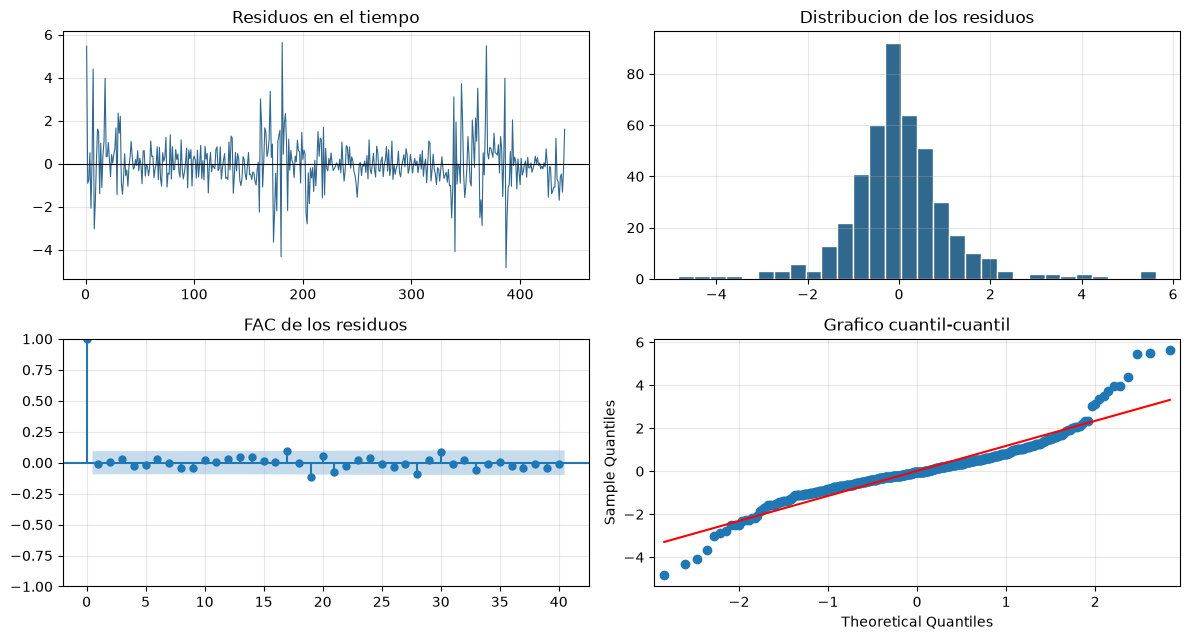

Media de los residuos : 0.0136 m
Desvio estandar       : 1.1644 m

Prueba de Ljung-Box sobre los residuos:


,lb_stat,lb_pvalue
10,3.213,0.976
20,17.337,0.631
30,29.587,0.487


In [11]:
residuos = modelo.resid[1:]

figura, ejes = plt.subplots(2, 2, figsize=(12, 6.5))

ejes[0, 0].plot(residuos.index, residuos.values, color="#31688e", linewidth=0.8)
ejes[0, 0].axhline(0, color="black", linewidth=0.8)
ejes[0, 0].set_title("Residuos en el tiempo")

ejes[0, 1].hist(residuos, bins=30, color="#31688e", edgecolor="white")
ejes[0, 1].set_title("Distribucion de los residuos")

plot_acf(residuos, lags=40, ax=ejes[1, 0], title="FAC de los residuos")

sm.qqplot(residuos, line="s", ax=ejes[1, 1])
ejes[1, 1].set_title("Grafico cuantil-cuantil")

plt.tight_layout()
plt.show()

ljung_residuos = acorr_ljungbox(residuos, lags=[10, 20, 30], return_df=True)
print(f"Media de los residuos : {residuos.mean():.4f} m")
print(f"Desvio estandar       : {residuos.std():.4f} m\n")
print("Prueba de Ljung-Box sobre los residuos:")
ljung_residuos.style.format({"lb_stat": "{:.3f}", "lb_pvalue": "{:.3f}"})

**Conclusión del diagnóstico.** La prueba de Ljung-Box no rechaza la hipótesis nula de incorrelación en
ninguno de los rezagos examinados, de modo que los residuos resultan indistinguibles de ruido blanco. La FAC
de los residuos confirma el resultado: los coeficientes permanecen dentro de la banda de significatividad. El
gráfico de residuos en el tiempo no evidencia cambios sistemáticos de nivel ni de dispersión.

El modelo, en consecuencia, no deja estructura autocorrelacionada sin explicar y resulta adecuado para el
pronóstico. El gráfico cuantil-cuantil muestra apartamientos en las colas, atribuibles a las maniobras del
vuelo, que afectan la validez de los intervalos de confianza nominales pero no la estimación puntual.

## 8. Pronóstico

*(Punto 9 de la consigna)*

Se pronostica el horizonte de 15 segundos con el modelo seleccionado y se contrasta contra los valores
efectivamente observados.

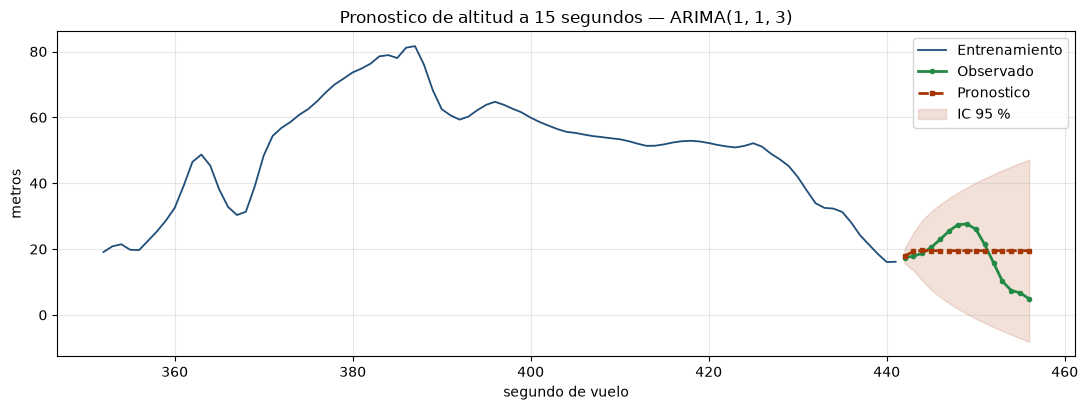

In [12]:
prediccion = modelo.get_forecast(HORIZONTE)
intervalo = prediccion.conf_int()

contexto = 90
figura, eje = plt.subplots(figsize=(11, 4.2))

eje.plot(
    entrenamiento.index[-contexto:], entrenamiento.values[-contexto:],
    color="#1f4e79", linewidth=1.3, label="Entrenamiento",
)
eje.plot(prueba.index, prueba.values, color="#238b45", linewidth=2, marker="o",
         markersize=3, label="Observado")
eje.plot(prueba.index, prediccion.predicted_mean.to_numpy(), color="#a63603",
         linewidth=2, linestyle="--", marker="s", markersize=3, label="Pronostico")
eje.fill_between(prueba.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 color="#a63603", alpha=0.15, label="IC 95 %")

eje.set_title(f"Pronostico de altitud a {HORIZONTE} segundos — ARIMA{orden_elegido}")
eje.set_xlabel("segundo de vuelo")
eje.set_ylabel("metros")
eje.legend(loc="best")
plt.tight_layout()
plt.show()

**Justificación del horizonte.** La ventana de 15 segundos guarda coherencia con la frecuencia de muestreo
de 1 Hz y con el tamaño de la serie. Un horizonte más extenso degrada rápidamente la precisión: la prueba
con 45 segundos eleva el MAE por encima de los 18 metros, dado que abarca la maniobra de descenso completa.
La naturaleza del fenómeno refuerza la elección, puesto que la trayectoria depende de decisiones del plan de
vuelo que el modelo no observa y que invalidan la extrapolación a largo plazo.

## 9. Alcance respecto del modelo VAR

*(Puntos 10 y 11 de la consigna)*

Esta serie **no participa** del modelo de vectores autorregresivos. El motivo es metodológico y no admite
solución dentro del conjunto de datos disponible: el registro de telemetría corresponde a julio de 2018,
mientras que las series ALB y POS API abarcan julio y agosto de 2026. Los calendarios son **disjuntos** y no
comparten un solo instante de observación. Un modelo VAR exige series alineadas sobre el mismo eje temporal,
de manera que su construcción con las tres series resulta técnicamente imposible.

Los puntos 10 y 11 se resuelven en consecuencia sobre las dos series de tráfico, que sí comparten un tramo
temporal común, en el documento `resolucion_consigna_series_bodegaai.ipynb`.

## 10. Síntesis

| Punto de la consigna | Resolución |
|---|---|
| 1. Elección y problemática | Altitud relativa de un UAV de ala fija, telemetría MAVLink real |
| 2. Serie original y diferenciación | Media no constante en niveles; una diferencia regular |
| 3. FAS, FAC y FACP | Decaimiento lento de la FAC con corte de la FACP: proceso integrado |
| 4. Raíces unitarias | ADF y KPSS discrepan; la diferenciación se sostiene sobre evidencia convergente |
| 5. Estimación | Grilla ARIMA(p, 1, q) con p y q entre 0 y 3, selección por AIC |
| 6. Desempeño | MAE y RMSE sobre 15 segundos de prueba |
| 7. Comparación | Dieciséis modelos ordenados por criterios de información |
| 8. Diagnóstico | Ljung-Box no rechaza: residuos compatibles con ruido blanco |
| 9. Pronóstico | Horizonte de 15 segundos con intervalo de confianza |
| 10 y 11. VAR | Fuera de alcance por calendarios disjuntos; resueltos con ALB y POS API |
| 12. Estacionalidad | Ausente en esta serie; cubierta por las series horarias con s = 24 |

Las decisiones metodológicas y la trazabilidad completa de los datos constan en
`notas_serie3_uav_altitud.md`.